In [1]:
using Pipe
# using MarketTechnicals
# using Plots
# using TimeSeries
using DataFrames
# using StatsPlots
using CSV
# using RollingFunctions
using Query
# using GLMakie

using JSON
using DataFrames
using Dates
using Colors
using ColorSchemes
using Indicators
using JSONTables
using JSON3

import Colors
using Plots
using Interact
using Evolutionary

In [2]:
json_data_folder = "/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance"
ba,qa,tfr = "BTC","USDT","1d"
# "$(ba)_$(qa)-$(tfr).json"
fname = "$json_data_folder/$(ba)_$(qa)-$(tfr).json"
json_string = read(fname, String)
json_data = JSON3.read(json_string)

odf = DataFrame(ts = Int64[], open=Float64[], high=Float64[], low=Float64[], close=Float64[], volume=Float64[])
for r in json_data push!(odf, r) end
# dfa.unix_time .= dfa.unix_time ./1000
# dfa.time .= unix2datetime.(dfa.unix_time)


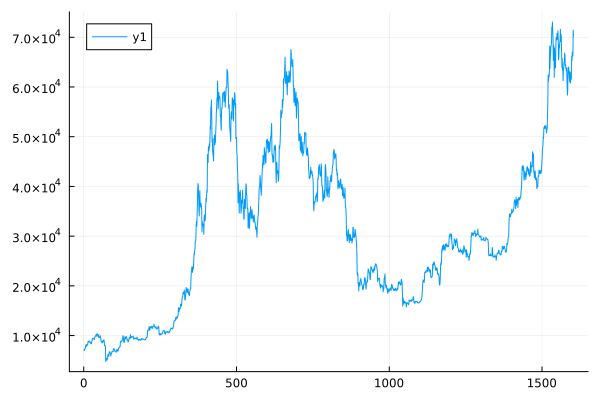

In [3]:
plot(odf.close)

In [4]:
nrow(odf)

1603

In [5]:
function donch(hl::AbstractMatrix{T}; n::Int64=10, inclusive::Bool=true)::Matrix{Float64} where {T<:Real}
    @assert size(hl,2) == 2 "Argument `hl` must have exactly 2 columns."
    local lower::Array{T} = runmin(hl[:,2], n=n, cumulative=false, inclusive=inclusive)
    local upper::Array{T} = runmax(hl[:,1], n=n, cumulative=false, inclusive=inclusive)
    local middle::Array{T} = (lower .+ upper) ./ 2.0
    return [lower middle upper]
end
function shft(x::AbstractVector{T} where T<:Number, n::Integer, fillVal=NaN)
    if n == 0
        return x
    elseif n < 0
        return vcat(x[1-n:end], fill(fillVal, -n))
    else
        return vcat(fill(fillVal, n), x[1:end-n])
    end
end
function ichimoku(hlc::AbstractMatrix{T}; params=(10, 26, 26, 52))::Matrix{Float64} where {T<:Real}
    # Source: https://www.investopedia.com/terms/i/ichimokuchart.asp
    # TODO: Implement option to get forward looking Senkous
    @assert size(hlc,2) == 3 "Argument `hlc` must have exactly 3 columns."
    tenkan = donch(hlc[:,1:2]; n=params[1], inclusive=true)[:,2]
    kijun = donch(hlc[:,1:2]; n=params[2], inclusive=true)[:,2]
    senkoua = shft((tenkan + kijun) /2, params[3])
    senkoub = shft(donch(hlc[:,1:2]; n=params[4], inclusive=true)[:,2], params[3])
    # chikou = shft(hlc[:,3], params[5])
    return [tenkan kijun senkoua senkoub]
end

ichimoku (generic function with 1 method)

In [6]:
2  in [4,3]

false

In [27]:
function xstrategy(odf::DataFrame, xparams)
    tenN,kijN,senaN,senbN = xparams
    n = nrow(odf)
    lclose = log.(odf.close)
    ichi = ichimoku(Matrix(odf[:,[:high,:low,:close]]); params=(tenN,kijN,senaN,senbN))
    tenkan,kijun,senkA,senkB = [view(ichi, :, i) for i in 1:size(ichi, 2)]
    ###
    senkU = max.(senkA,senkB)
    senkL = min.(senkA,senkB)
    tBk = tenkan .> kijun
    maskLong = tBk .&& (odf.close .> senkU) 
    sigLong = (.! shft(maskLong,1,true)) .&& maskLong
    maskLongEx = (odf.close .<= senkU) 
    maskLongEx[end] = true

    isigLong = (1:n)[sigLong]
    trades = zeros(n)
    inpos = false
    for i in 1:n 
        if (!inpos) && sigLong[i]
        trades[i] = 1 
        inpos = true
        elseif (inpos) && maskLongEx[i]
            trades[i] = -1
            inpos = false
        end
    end
    if inpos trades[n] = -1 end
    ilong = findall(x->x==1, trades)
    iexit = findall(x->x==-1, trades)
    pnl = lclose[iexit] .- lclose[ilong]
    cpnl = cumsum(pnl)
    return ilong, iexit, pnl, cpnl
end


# xstrategy(odf)

###!!! Vectorized
# xlong = vcat(isigLong,[n])
# longPer = [xlong[il]:xlong[il+1]-1 for il in 1:length(xlong)-1]
# # longPer = [xlong[il]:n for il in 1:length(xlong)-1]
# ilongEx = [
#     # b[1]+findfirst(maskLongEx[b]) 
#     # findfirst(maskLongEx[b])
#     sum(maskLongEx[b]) 
#     # b
#     for b in longPer
    
# ]

xstrategy (generic function with 4 methods)

In [18]:
x0 = [20,60,120,30]
# tenN,kijN,senaN,senbN = x0
trunc.(x0)

4-element Vector{Int64}:
  20
  60
 120
  30

In [28]:


function obj(x) 
    pars = trunc.(x)
    println("----------------")
    println(pars)
    -xstrategy(odf, pars)[end][end] 
    # -1
end
# obj(params)
ga = GA(populationSize=20)
lower = [3, 3,3,3]
upper = [200, 200, 200, 200]
Evolutionary.optimize(obj, BoxConstraints(lower, upper), x0, ga, Evolutionary.Options(iterations=20))

----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]
----------------
[20, 60, 120, 30]


InexactError: InexactError: Int64(20.807917000389622)

In [ ]:

# ichimoku(odf[:,[:high,:low,:close]], params=(tenN,kijN,senbN))
# ws,ww = 1100,500; we=ws+ww
ws,we = 1,n

iwlong = [x for x in ilong if x in ws:we]
iwexit = [x for x in iexit if x in ws:we]
plot(ws:we,odf.close[ws:we],size=(1500,400);label="close", linewidth=2)
plot!(ws:we,ichi[ws:we,1];label="tenkan", linecolor=:blue)
plot!(ws:we,ichi[ws:we,2];label="kijun", linecolor=:red)
plot!(ws:we,ichi[ws:we,3], fillrange = ichi[ws:we,4], fillalpha = 0.35, fillcolor=:gray)
plot!(twinx(),vcat([0],iexit), vcat([0],cpnl), linewidth=3, linecolor=:orange)
vline!(iwlong)
vline!(iexit, linecolor=:red)
# plot!(ichi[ws:we,3:4], fillcolor = plot_color(:yellow, 0.3))